## EDA Part 1: Distributions & Outliers
Exploratory Data Analysis (EDA) is a first step to constructing machine learning models. it includes an overview of data distributions,detecting outlires and exploring categroal variables via visulization

In [4]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv("student_performance_dataset.csv")


## Example 1-Histogram
a histogram shows the distribution of numeric data values.This plot allows us to understand if the data is normally distributed,skewed,or multimodel. 

In [5]:
df.head()

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A
3,4,Male,2.6,77.5,8.0,NaN,Yes,Yes,No,85.1,83.8,B
4,5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D


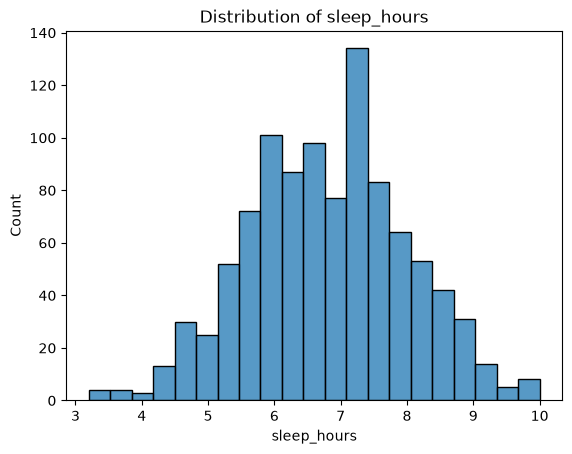

In [6]:
sns.histplot(data=df,x="sleep_hours")
plt.title("Distribution of sleep_hours")
plt.show()

## Observation
This histogram shows the distribution of sleep time which follows a bell-shaped and symmetrical distribution with a peek at 7 hours.

## Example-2 - KDE Plot
A Kernal Desity Estimate (KDE) plot is a plot without bars.

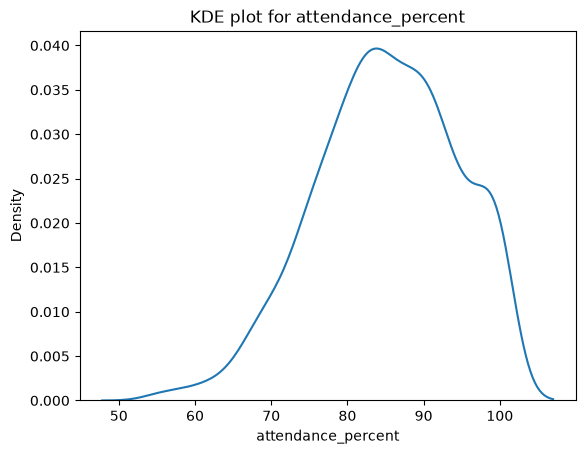

In [7]:
sns.kdeplot(data=df,x="attendance_percent")
plt.title("KDE plot for attendance_percent")
plt.show()

## Observation
This KDE plot shows the distribution of attendance_percent indicating where most data points are connected

## Example 3 - Box Plot
a bos plot summarize the distribution using the mean ,potential outliers and quartiles

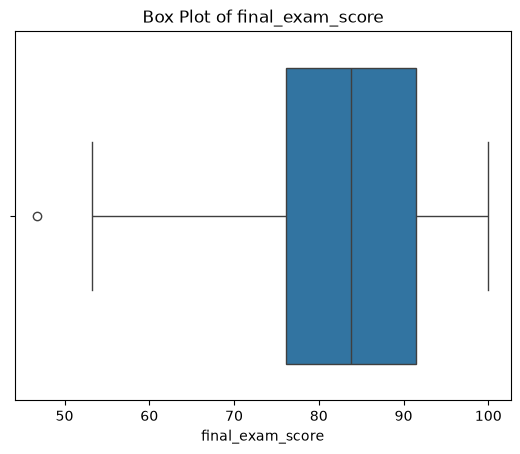

In [8]:
sns.boxplot(x=df["final_exam_score"])
plt.title("Box Plot of final_exam_score")
plt.show()

## Observation
This Plot shows the distribution of final exam scores with the median and quartiles as well as outlier.

## Example 4 - Count Plot
this plot shows the frequency of each category

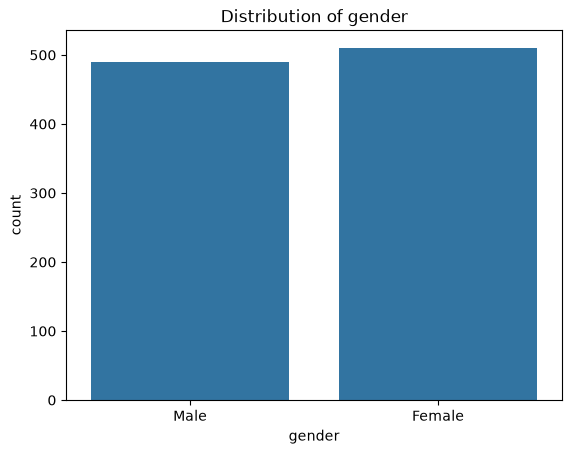

In [10]:
sns.countplot(data=df,x="gender")
plt.title("Distribution of gender")
plt.show()

## Observation
This count plot shows the distribution of genders which seems to have a relatively equal count between men and women.

## Example 5 -Detecting Outliers with the IQR method
Outliers are data points that differ significatntly from other observations in the dataset.

In [11]:
Q1=df["sleep_hours"].quantile(0.25)
Q3=df["sleep_hours"].quantile(0.75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR
print("lower bound:",lower)
print("upper bound",upper)

lower bound: 3.3500000000000014
upper bound 10.149999999999999


In [13]:
outliers=df[(df["sleep_hours"]<lower)|(df["sleep_hours"]>upper)]
print("outliers:",outliers)

outliers:      student_id gender  study_time_hours  attendance_percent  sleep_hours  \
561         562   Male               2.5                84.7          3.2   
766         767   Male               2.5                85.2          3.3   

    parental_education internet_access extracurricular_activities  \
561          Bachelors              No                         No   
766          Bachelors             Yes                         No   

    part_time_job  previous_grade  final_exam_score final_grade  
561            No            90.1              83.9           B  
766            No            60.1              83.9           B  


Using the IQR method two outliers were detected in the sleep hours (column student sleeping less than 3.35 hours)

## Hands-On-Lab
Step 1: Load a provided real dataset and produce a histogram for each numeric variable.


In [14]:
df.head()
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  1000 non-null   int64  
 1   gender                      1000 non-null   str    
 2   study_time_hours            1000 non-null   float64
 3   attendance_percent          1000 non-null   float64
 4   sleep_hours                 1000 non-null   float64
 5   parental_education          898 non-null    str    
 6   internet_access             1000 non-null   str    
 7   extracurricular_activities  1000 non-null   str    
 8   part_time_job               1000 non-null   str    
 9   previous_grade              1000 non-null   float64
 10  final_exam_score            1000 non-null   float64
 11  final_grade                 1000 non-null   str    
dtypes: float64(5), int64(1), str(6)
memory usage: 93.9 KB


In [15]:
num_col=df.select_dtypes(include="number").columns
print(num_col)

Index(['student_id', 'study_time_hours', 'attendance_percent', 'sleep_hours',
       'previous_grade', 'final_exam_score'],
      dtype='str')


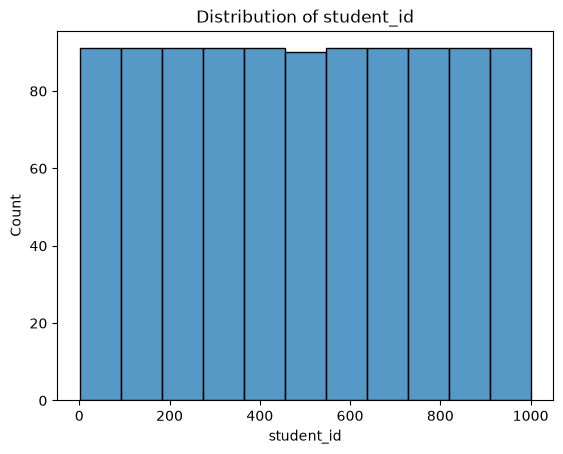

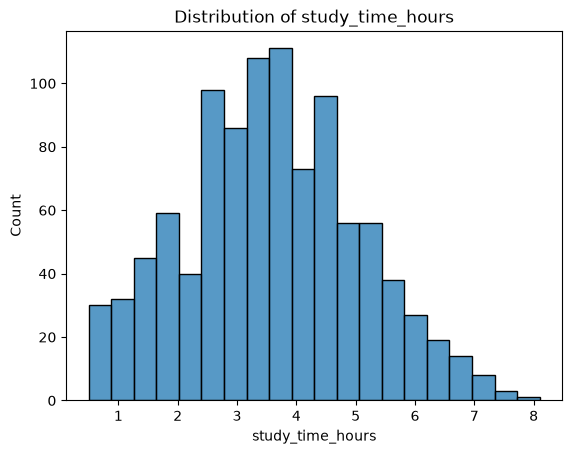

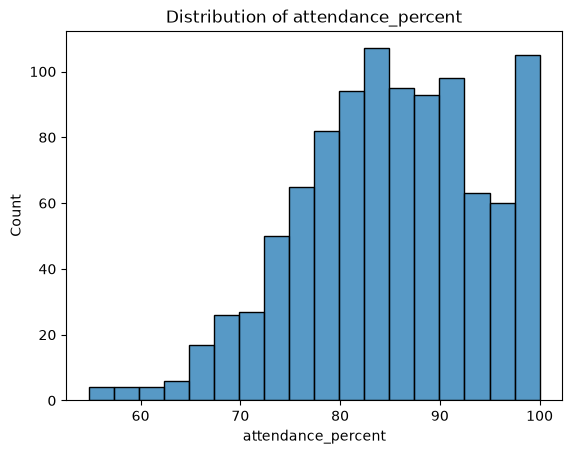

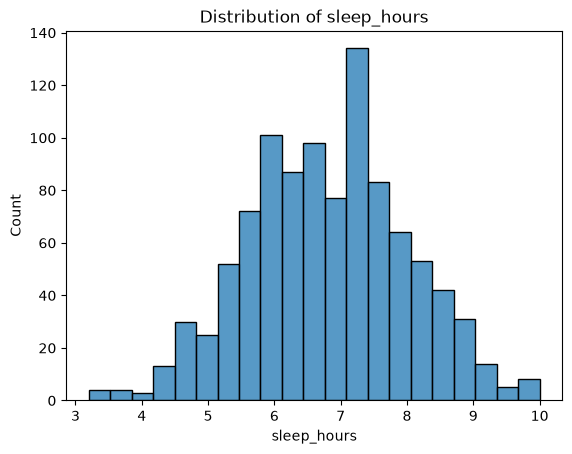

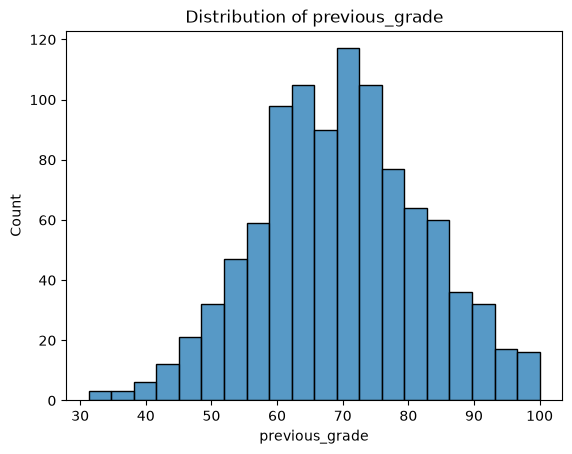

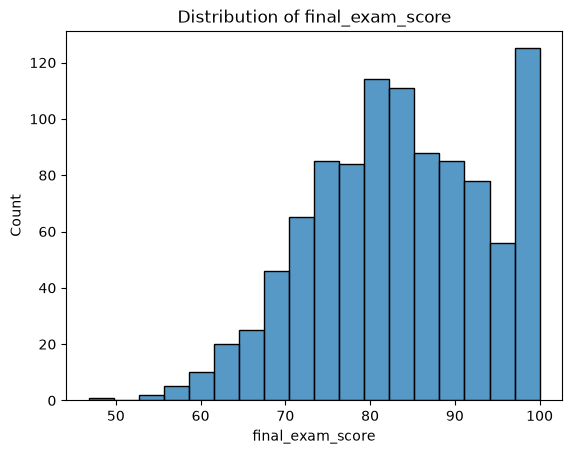

In [16]:
for num in num_col:
    sns.histplot(data=df,x=num)
    plt.title(f"Distribution of {num}")
    plt.show()

 Step 2: Produce a box plot for the key numeric variables and identify any outliers visually.


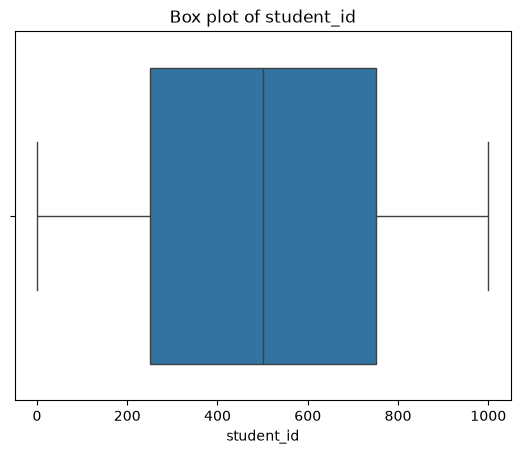

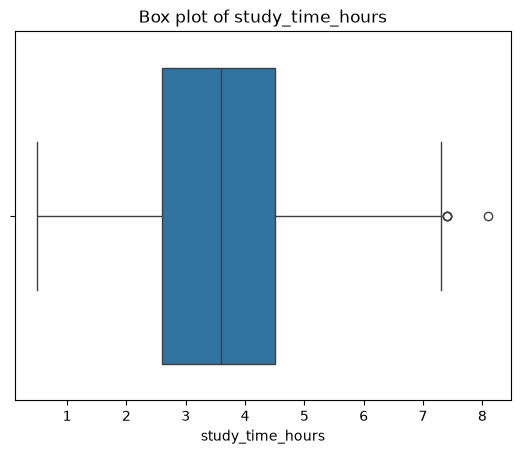

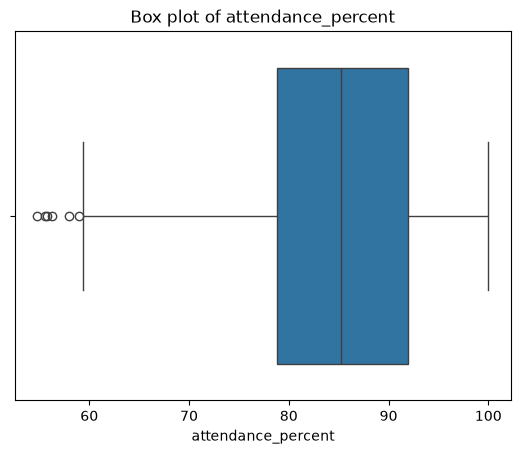

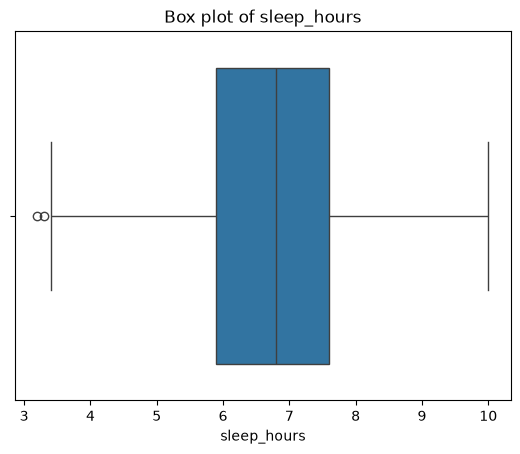

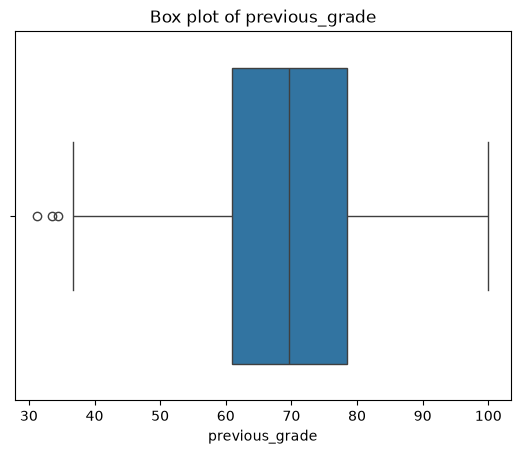

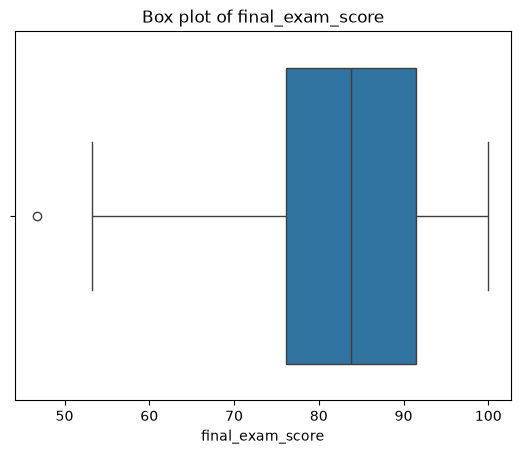

In [17]:
for num in num_col:
    sns.boxplot(x=df[num])
    plt.title(f"Box plot of {num}")
    plt.show()

Step 3: Apply the IQR method in code to flag outliers in at least one column, and decide (with justification)
how to handle them

In [19]:
Q1=df["final_exam_score"].quantile(0.25)
Q3=df["final_exam_score"].quantile(0.75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR
print("lower bound:",lower)
print("upper bound",upper)

lower bound: 52.89999999999996
upper bound 114.70000000000003


In [20]:
outliers=df[(df["final_exam_score"]<lower)|(df["final_exam_score"]>upper)]
print("outliers:",outliers)

outliers:      student_id gender  study_time_hours  attendance_percent  sleep_hours  \
147         148   Male               1.7                83.5          5.7   

    parental_education internet_access extracurricular_activities  \
147            Masters             Yes                        Yes   

    part_time_job  previous_grade  final_exam_score final_grade  
147           Yes            59.2              46.8           F  


In [21]:
outliers["final_exam_score"]


147    46.8
Name: final_exam_score, dtype: float64

In [22]:
print("Number of outliers=",len(outliers))

Number of outliers= 1


In [ ]:
cat_col=df.select_dtypes(include="object").columns
print(cat_col)


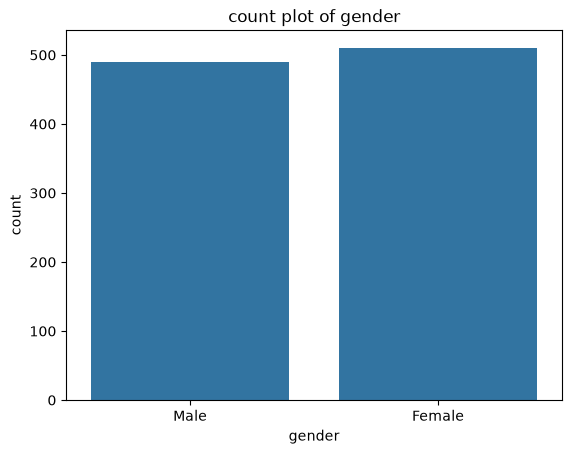

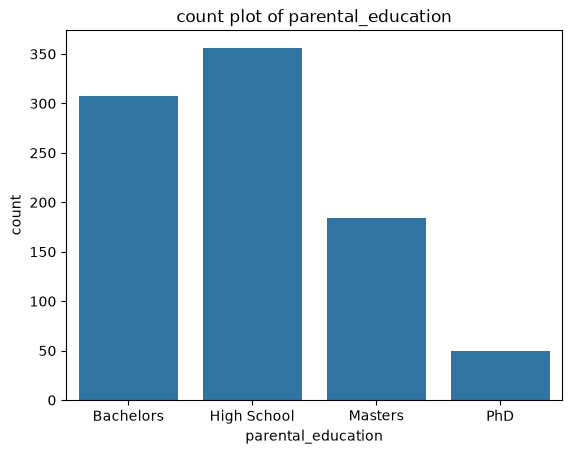

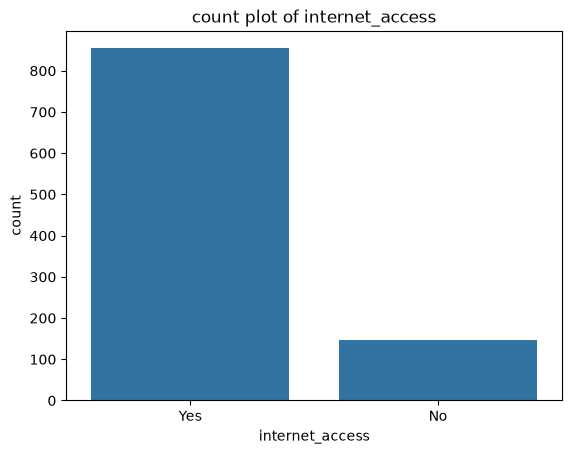

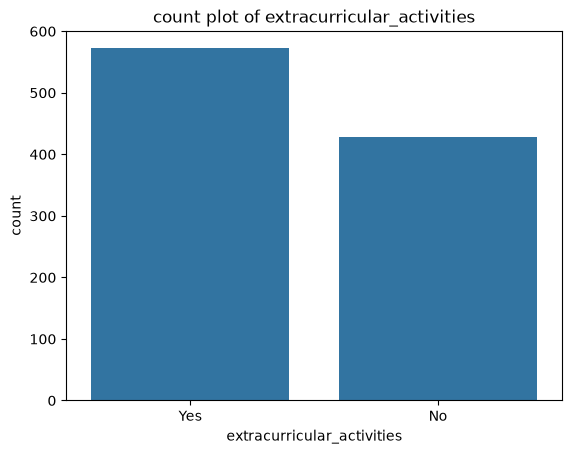

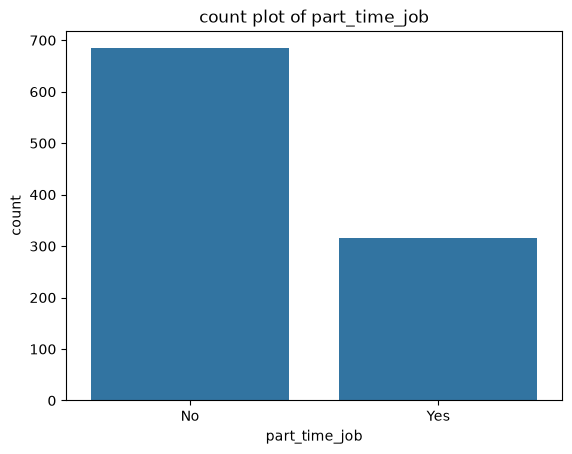

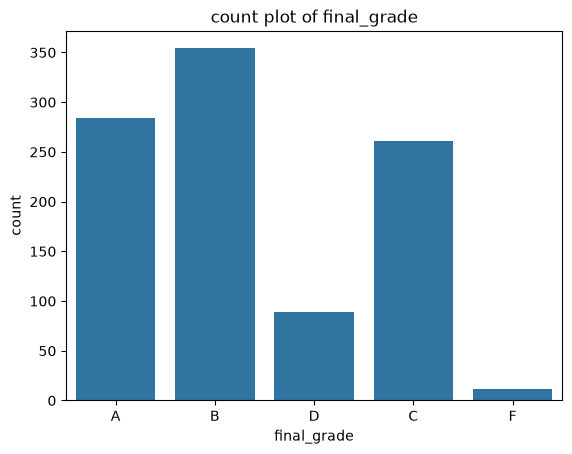

In [26]:
for c in cat_col:
    sns.countplot(data=df,x=c)
    plt.title(f"count plot of {c}")
    plt.show()